<a href="https://colab.research.google.com/github/DrGPCR/NEUR201/blob/main/Unit_1/notebooks/W2L2_Colocalization_analysis__STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W2L2 — Colocalization Analysis of a Confocal Image

**NEUR 201 — Research Methods & Data Analysis for Cellular Neuroscience**

**Name:** *(double-click to type)*  **Date:** *(double-click to type)*

---

## The scenario

You are a scientist trying to work out **cellular identity**.

Look at a DAPI-stained brain section and you will see thousands of nuclei. They are the most obvious
thing in the image and, on their own, almost the least informative: a nucleus tells you a cell is
there, but not what kind of cell it is or what it is doing. An oligodendrocyte precursor, a mature
neuron, a microglial cell and a dividing progenitor all look about the same in blue.

Antibodies are how you get past that. Each one binds a specific protein, and each protein is present
only in cells of a certain **type** or in a certain **state**. Stain for one and you have divided the
tissue into two groups: cells that have the protein, and cells that don't.

The catch is that one antibody rarely answers a real question. Today's image was stained for two:

- **Ki67** tells you about **state** — a cell makes it only while actively dividing.
- **Olig2** tells you about **lineage** — it marks cells of the oligodendrocyte lineage.

Ki67 alone tells you cells are dividing, but not which ones. Olig2 alone tells you the lineage is
present, but not whether it is expanding. Neither question is answered until you find the cells that
carry **both** labels at once, and that is what you'll do here. The technique is called
**colocalization**, and it is one of the main ways cellular identity gets established in practice.

By the end you'll have a number for how many cells of this lineage were dividing when the animal was
perfused — plus a clear sense of how much that number depended on decisions you made along the way.

---

## The image

You have one confocal image (a `.czi` file from a Zeiss microscope) of a brain section. The section was
stained with two antibodies and a nuclear counterstain, and each was visualised with a different
fluorescent dye. The microscope recorded each dye separately, as its own **channel**:

| Channel | Antibody | What that antibody binds |
|---|---|---|
| DAPI | — | DNA, so every nucleus in the field |
| **Alexa 488** | anti-**Ki67** | Ki67, a protein made only by cells that are **actively dividing** |
| **Alexa 594** | anti-**Olig2** | Olig2, a transcription factor found in **oligodendrocyte-lineage cells** |

From here on each channel is named by its dye and its antibody together — **Alexa 488 (Ki67)** and
**Alexa 594 (Olig2)** — because you need both. The dye is what the microscope recorded; the antibody is
what it means.

## What a channel actually is

A channel is not a picture in the everyday sense. It is a grid of numbers, one per pixel, and each
number is how much light the detector collected at that spot. In this image those numbers run from a
few hundred up to about 40,000 — brighter staining means a bigger number, and nothing more.

That matters, because it means "is there a cell here?" is not a question the file answers. It is a
question **you** answer, by choosing a number above which a pixel counts as staining. Making that
choice, and seeing what it does to your results, is the point of today.

## What you'll be able to do by the end

1. Explain what Olig2 and Ki67 label, and why an Olig2⁺Ki67⁺ cell is a proliferating
   oligodendrocyte-lineage cell
2. Run a **segmentation pipeline**: thresholding, size filtering, and labelling
3. Explain how **mask overlap** identifies double-positive cells, and where that can mislead
4. Compute densities in **cells per mm²** and the **colocalization ratio**, and say why normalising
   matters
5. Judge how much to trust a result given the settings you chose

## How this notebook works

**Run every cell in order, from the top.** Click a cell and press **Shift + Enter**.

You'll see three kinds of things along the way:

| | What to do |
|---|---|
| **Ordinary cells** | Just run them. You don't need to understand every line of code. |
| **⚙️ Try it** | Change the highlighted value, re-run the cell, and see what happens. |
| **💬 Discussion** | Double-click the cell and type your answer. We'll discuss these in class. |

If something breaks, first check that you ran **every cell above it**.

---

## Step 1 — Set up and load the image

Two things happen here.

First we install `czifile`. Python cannot read Zeiss `.czi` files on its own, so we add a library that
can. `--quiet` just hides the installation messages.

Then we download the image from the course GitHub. The `if not os.path.exists(...)` check means it only
downloads once — run the cell again and it will skip straight past.

> **If the download fails:** click the 📁 folder icon in the left sidebar, upload `Image_1.czi` by hand,
> then run this cell again.

In [9]:
!pip install czifile imagecodecs --quiet

import os                       # for checking whether a file already exists
import re                       # for pulling the pixel size out of the metadata text
import urllib.request           # for downloading the image
import numpy as np              # for working with the grid of pixel values
import pandas as pd             # for the results table at the end
import matplotlib.pyplot as plt # for every figure in this notebook
from czifile import CziFile     # for opening the .czi file
from skimage.measure import label, regionprops   # for finding and measuring blobs

IMAGE_FILE = "Image_1.czi"
URL = "https://raw.githubusercontent.com/DrGPCR/NEUR201/main/Unit_1/images/" + IMAGE_FILE

if not os.path.exists(IMAGE_FILE):
    print("Downloading", IMAGE_FILE, "...")
    try:
        urllib.request.urlretrieve(URL, IMAGE_FILE)
    except Exception:
        print("\n*** The download did not work. ***")
        print("Click the folder icon in the left sidebar, upload " + IMAGE_FILE + ",")
        print("then run this cell again.")
        raise SystemExit

print("Ready.", IMAGE_FILE, "is", round(os.path.getsize(IMAGE_FILE) / 1e6, 1), "MB")

Ready. Image_1.czi is 10.9 MB


## Step 2 — Open the image and look at it

Before measuring anything, look at what you are measuring. Almost every analysis mistake is visible in
the picture before it shows up in the numbers.

### Why we read the metadata

A `.czi` file stores more than pixels. The microscope also writes down **how large one pixel was** on
the actual tissue. Without that number your results are stuck in pixel units, and pixels are
meaningless to anyone using a different objective lens. With it, you can report **cells per mm²** —
which anybody can compare against their own data.

The code below pulls the pixel size out of the metadata, then uses it to work out the total area of
tissue in the field of view.

In [10]:
# Open a .czi file and return the three channels plus the pixel size in microns
def open_image(path):
    with CziFile(path) as czi:
        # The metadata is one long piece of text. The pixel size is buried in it, in metres,
        # so we search for it and multiply by 1e6 to convert metres -> microns.
        metadata = czi.metadata()
        x_size = float(re.search(r'Distance Id="X">\s*<Value>([^<]+)<', metadata).group(1)) * 1e6

        # asarray() gives the pixel values. squeeze() drops unused dimensions
        # (this image has no z-stack or time series), leaving (channel, y, x).
        data = np.squeeze(czi.asarray())

    # This microscope saved the channels in the order Alexa 488, DAPI, Alexa 594.
    channels = {"Alexa488": data[0], "DAPI": data[1], "Alexa594": data[2]}
    return channels, x_size


channels, pixel_microns = open_image(IMAGE_FILE)

# .shape gives the size of the pixel grid, as (rows, columns) = (height, width)
height, width = channels["DAPI"].shape

# Area of one pixel = side x side. Divide by 1e6 at the end because 1 mm² = 1,000,000 µm².
area_mm2 = (height * width * pixel_microns * pixel_microns) / 1e6

print("Image size:", width, "x", height, "pixels")
print("One pixel is", round(pixel_microns, 3), "microns across")
print("Total imaged area:", round(area_mm2, 4), "mm²")

Image size: 445 x 478 pixels
One pixel is 0.651 microns across
Total imaged area: 0.0902 mm²


### The three channels, one at a time

Each channel is displayed in greyscale below: brighter pixel = bigger number.

One display note. `vmax=np.percentile(image, 99.5)` tells matplotlib to treat the 99.5th-percentile
value as pure white, so the brightest 0.5% of pixels are clipped. This is only to make the image
easier to see on screen — **it changes nothing about the data**, and no measurement below is affected
by it.

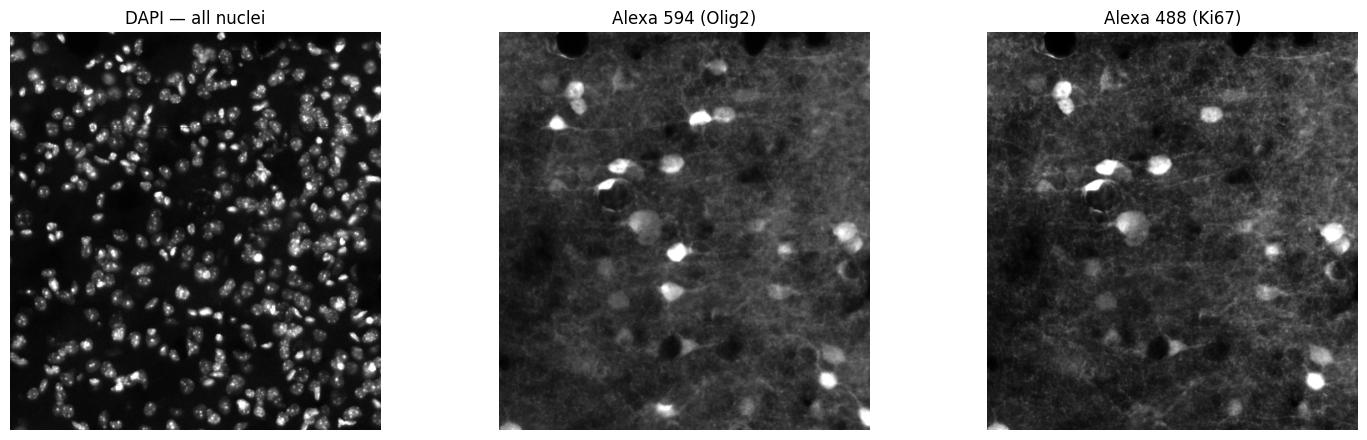

In [11]:
plt.figure(figsize=(15, 4.5))

# Loop over the three channels, drawing each one into its own panel
for position, (name, title) in enumerate([("DAPI", "DAPI — all nuclei"),
                                          ("Alexa594", "Alexa 594 (Olig2)"),
                                          ("Alexa488", "Alexa 488 (Ki67)")]):
    plt.subplot(1, 3, position + 1)        # 1 row, 3 columns, this panel
    plt.imshow(channels[name], cmap="gray", vmax=np.percentile(channels[name], 99.5))
    plt.title(title)
    plt.axis("off")                        # hide the pixel-coordinate axes

plt.tight_layout()
plt.show()

### All three at once

Now the same three channels combined into one colour picture, called a **composite**. Alexa 594 (Olig2)
is shown in red, Alexa 488 (Ki67) in green, and DAPI in blue. Where red and green fall on the same
spot, the mix shows up **yellow** — those are the cells you are looking for.

The colours are a display choice, not a property of the dyes. Any channel could be shown in any colour,
and the convention only exists to make overlaps easy to spot by eye.

**Look at this image carefully before moving on.** Roughly how many yellow cells can you count? Keep
that number in mind — you'll compare it against what the computer finds.

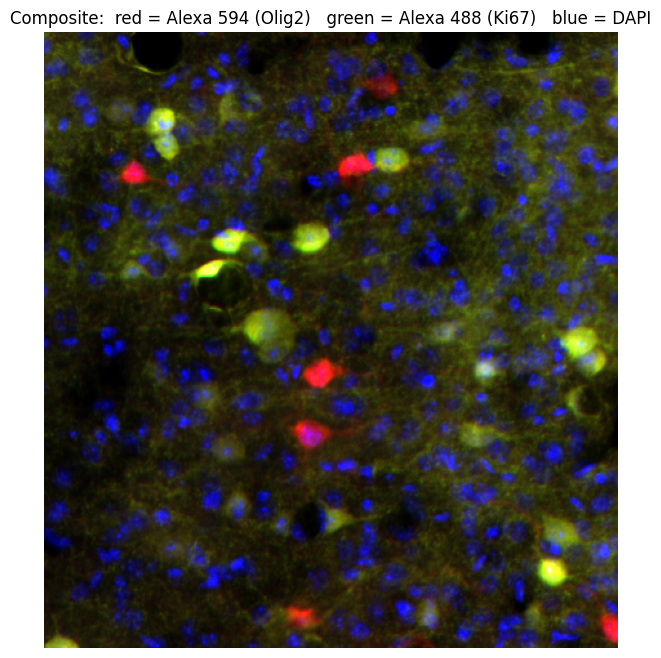

In [12]:
def stretch(image):
    low, high = np.percentile(image, 1), np.percentile(image, 99.7)
    return np.clip((image - low) / (high - low), 0, 1)


# np.dstack stacks three 2D images into one RGB image: red, then green, then blue
composite = np.dstack([stretch(channels["Alexa594"]),   # red
                       stretch(channels["Alexa488"]),   # green
                       stretch(channels["DAPI"])])      # blue

plt.figure(figsize=(8, 8))
plt.imshow(composite)
plt.title("Composite:  red = Alexa 594 (Olig2)   green = Alexa 488 (Ki67)   blue = DAPI")
plt.axis("off")
plt.show()

## Step 3 — Detecting the cells

The computer has no concept of a cell. It has a grid of numbers. Turning one into the other takes three
steps:

**1. Threshold.** Pick a brightness cut-off and keep only the pixels above it. The result is a **mask**:
a copy of the image where every pixel is either "signal" or "not signal". This is the step that decides
what counts as staining, and it is a judgement call — the file does not contain the answer.

**2. Size filter.** Thresholding also picks up things that are not cells: single bright noise pixels
(too small), and clumps where several touching cells merge into one object (too big). We keep only
objects between `MIN_SIZE` and `MAX_SIZE` pixels, which is roughly the size of one cell body.

**3. Label.** Every remaining separate blob is given its own number — blob 1, blob 2, blob 3 — so the
computer can count them and measure each one individually. `label()` does this by finding groups of
touching pixels.

The two cut-offs below were chosen for this image by looking at the result. Run the cell, then check
the pictures underneath: **the white shapes should sit on the bright cell bodies**, not on dim
background and not merged into large irregular patches.

In [13]:
# ⚙️ Try it — the brightness cut-offs. A pixel counts as signal only if it is brighter than this.
#    Raising a number makes it stricter (fewer cells). Lowering it makes it more permissive (more).
THRESHOLD_594 = 6000      # for Alexa 594 (Olig2)
THRESHOLD_488 = 16000     # for Alexa 488 (Ki67)

# Size filter, in pixels. An object smaller than MIN_SIZE is treated as noise;
# one larger than MAX_SIZE is treated as several cells stuck together.
MIN_SIZE, MAX_SIZE = 100, 3000


# Turn one channel into a mask of detected cells, plus a numbered version of that mask
def find_cells(image, threshold, min_size, max_size):
    # 1. Threshold: True where the pixel is brighter than the cut-off, False everywhere else
    mask = image > threshold

    # 2. Label every group of touching True pixels with its own number
    labelled = label(mask)

    # 3. regionprops measures each numbered blob. Keep only the ones of plausible size.
    good_blobs = [blob.label for blob in regionprops(labelled)
                  if min_size <= blob.area <= max_size]
    keep = np.isin(labelled, good_blobs)     # True only for pixels in a blob we kept

    # Re-label the survivors so they are numbered 1, 2, 3, ... with no gaps
    return keep, label(keep)


mask_594, labels_594 = find_cells(channels["Alexa594"], THRESHOLD_594, MIN_SIZE, MAX_SIZE)
mask_488, labels_488 = find_cells(channels["Alexa488"], THRESHOLD_488, MIN_SIZE, MAX_SIZE)

# .max() is the highest blob number, which is the same as how many blobs there are
print("Alexa 594+ (Olig2+) cells detected:", labels_594.max())
print("Alexa 488+ (Ki67+) cells detected: ", labels_488.max())

Alexa 594+ (Olig2+) cells detected: 8
Alexa 488+ (Ki67+) cells detected:  7


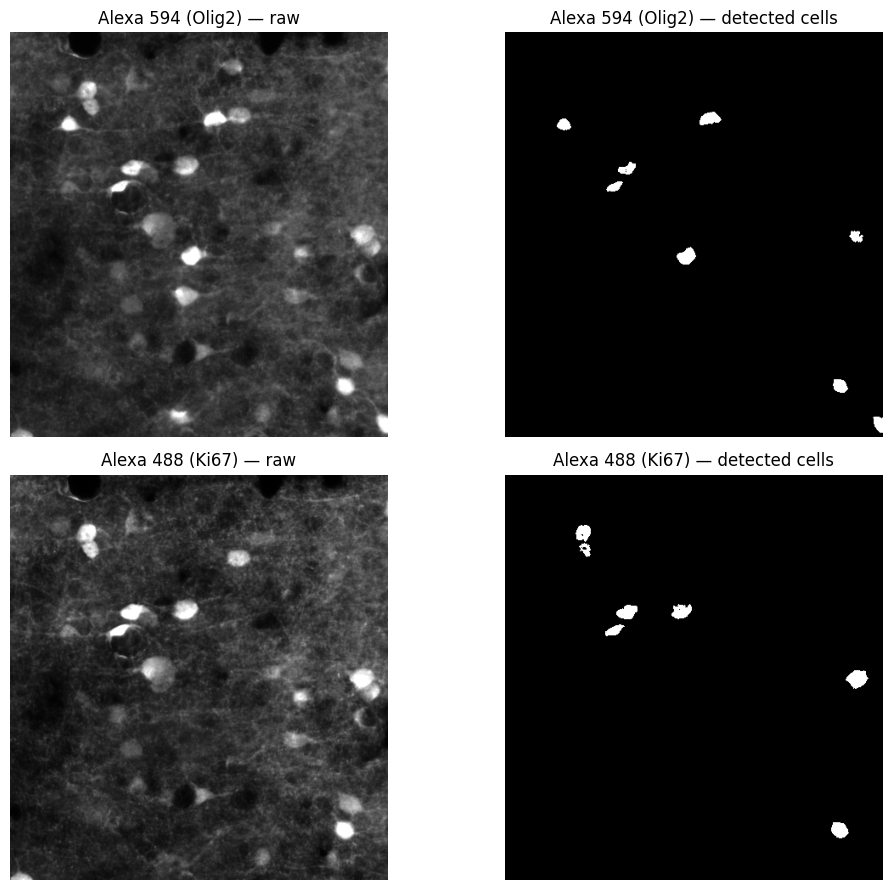

In [14]:
plt.figure(figsize=(11, 9))

# For each channel: the raw image on the left, what the computer detected on the right
for position, (name, title, mask) in enumerate([("Alexa594", "Alexa 594 (Olig2)", mask_594),
                                                ("Alexa488", "Alexa 488 (Ki67)", mask_488)]):
    plt.subplot(2, 2, position * 2 + 1)
    plt.imshow(channels[name], cmap="gray", vmax=np.percentile(channels[name], 99.5))
    plt.title(title + " — raw")
    plt.axis("off")

    plt.subplot(2, 2, position * 2 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(title + " — detected cells")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4 — Colocalization and your result

### Finding the double-positive cells

A pixel counts as **colocalized** only if it belongs to a detected cell in **both** channels at the same
time. `np.logical_and` does exactly that: it is True only where both masks are True. We then label the
overlap regions and count them.

### Turning counts into a result

A raw count is not yet a result, because it depends on how much tissue you photographed. Image twice the
area and you will find roughly twice the cells, with no biological difference at all. Dividing by the
imaged area gives a **density** in cells per mm², which is comparable across images.

We also compute the **colocalization ratio** — of all the Olig2⁺ cells, what proportion were also Ki67⁺:

$$\text{colocalization ratio} = \frac{\text{Alexa 488}^{+}\text{Alexa 594}^{+}\text{ cells}}{\text{Alexa 594}^{+}\text{ cells}}$$

A ratio is useful because it survives changes in how many cells happened to be in the frame. A density
tells you how crowded the tissue is; a ratio tells you about the cells themselves.

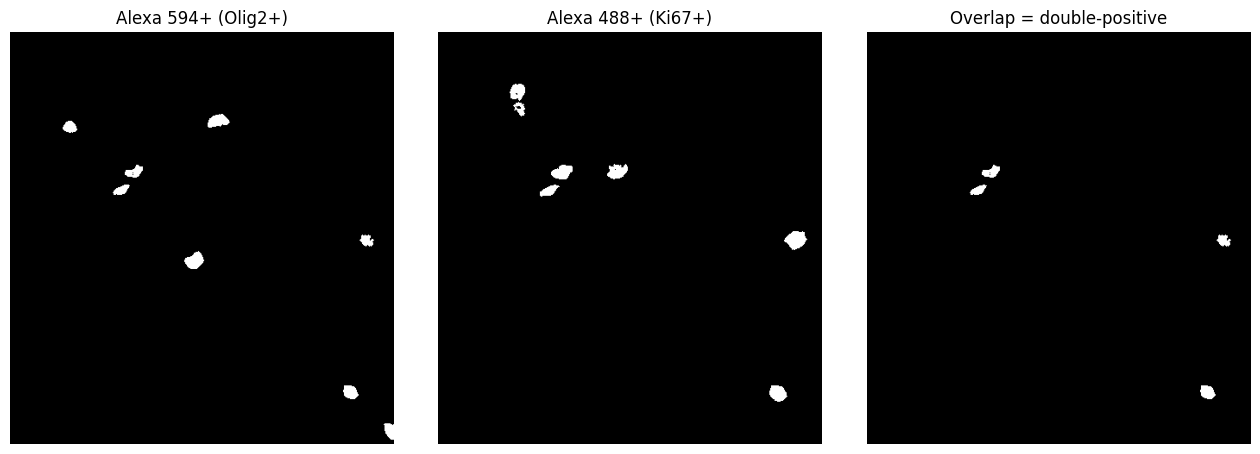

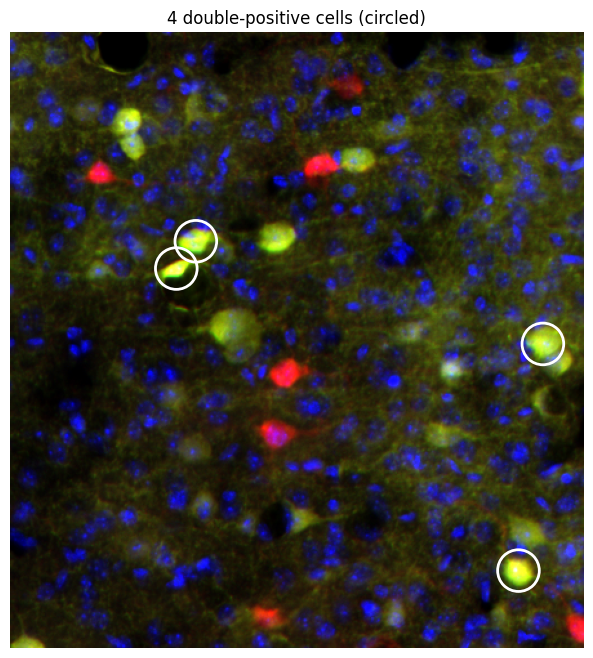

In [15]:
# A pixel is colocalized only if it was detected in BOTH channels
coloc_mask = np.logical_and(labels_594 > 0, labels_488 > 0)
coloc_labels = label(coloc_mask)          # number each overlap region
coloc_count = coloc_labels.max()          # and count them

plt.figure(figsize=(13, 4.5))
for position, (mask, title) in enumerate([(mask_594, "Alexa 594+ (Olig2+)"),
                                          (mask_488, "Alexa 488+ (Ki67+)"),
                                          (coloc_mask, "Overlap = double-positive")]):
    plt.subplot(1, 3, position + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Circle each double-positive cell on the composite, so you can check them against the real image
plt.figure(figsize=(8, 8))
plt.imshow(composite)
for blob in regionprops(coloc_labels):
    y, x = blob.centroid                  # the centre point of this overlap region
    plt.scatter(x, y, s=900, facecolors="none", edgecolors="white", linewidths=2)
plt.title(str(coloc_count) + " double-positive cells (circled)")
plt.axis("off")
plt.show()

In [16]:
count_594 = labels_594.max()
count_488 = labels_488.max()

# Guard against dividing by zero: if no Olig2+ cells were found there is no ratio to compute
if count_594 > 0:
    ratio = round(100 * coloc_count / count_594, 1)
else:
    ratio = np.nan

my_result = pd.DataFrame([{
    "Filename": IMAGE_FILE,
    "THRESHOLD_594": THRESHOLD_594,          # always record the settings that produced the numbers
    "THRESHOLD_488": THRESHOLD_488,
    "Olig2_Alexa594_Cells": count_594,
    "Ki67_Alexa488_Cells": count_488,
    "Colocalized_Cells": coloc_count,
    "Image_Area_mm2": round(area_mm2, 4),
    "Olig2_per_mm2": round(count_594 / area_mm2, 1),
    "Ki67_per_mm2": round(count_488 / area_mm2, 1),
    "Colocalized_per_mm2": round(coloc_count / area_mm2, 1),
    "Colocalization_ratio_pct": ratio,
}])

my_result.to_csv("my_image_result.csv", index=False)
print("Saved my_image_result.csv\n")

my_result.T          # .T flips the table on its side so it is easier to read

Saved my_image_result.csv



,0
Filename,Image_1.czi
THRESHOLD_594,6000
THRESHOLD_488,16000
Olig2_Alexa594_Cells,8
Ki67_Alexa488_Cells,7
Colocalized_Cells,4
Image_Area_mm2,0.0902
Olig2_per_mm2,88.7
Ki67_per_mm2,77.6
Colocalized_per_mm2,44.3


### 💬 Discussion

Talk these through with the person next to you, then type your answers here.

1. **What did you count?** Report your three numbers — Alexa 594⁺ (Olig2⁺), Alexa 488⁺ (Ki67⁺), and
   double-positive — together with the colocalization ratio. Compare the circled cells against the
   composite in Step 2: does the computer's count match what you counted by eye? If not, where does it
   disagree?

2. **What is a double-positive cell?** Ki67 is made only by dividing cells; Olig2 marks
   oligodendrocyte-lineage cells. Putting those together, what is a cell positive for **both**? And
   what would you conclude about a cell that is **Olig2⁺ but Ki67⁻**, or **Ki67⁺ but Olig2⁻**?

3. **What does the colocalization ratio tell you?** Report your ratio, then say in one sentence what
   it means — of *which* cells is it a proportion, and what is it telling you about them? A density
   (cells per mm²) and a ratio answer different questions: name something the ratio can tell you that
   `Olig2_per_mm2` cannot.

**Your answer:** *(double-click here to type)*

>
>
>

---
### Nice work — you're done!

Click **Runtime → Run all**, then **File → Print → Save as PDF**, and upload the PDF to Canvas.